In this Section we will cover Regression. In regression the target variable is always continous like GDP figures , House Prices etc.

In [1]:
import pandas as pd

df = pd.read_csv('data/diabetes_clean.csv')
df.head(10)

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [2]:
# Creating Target Variables

X = df.drop("glucose", axis=1).values
Y = df['glucose'].values

In [7]:
# Making BMI Prediction
X_Bmi = X[:,3]
print(Y.shape, X_Bmi.shape)

(768,) (768,)


In [12]:
# Reshapping as Sklearn required 2D array
X_Bmi = X_Bmi.reshape(-1,1)
print(Y.shape, X_Bmi.shape)

(768,) (768, 1)


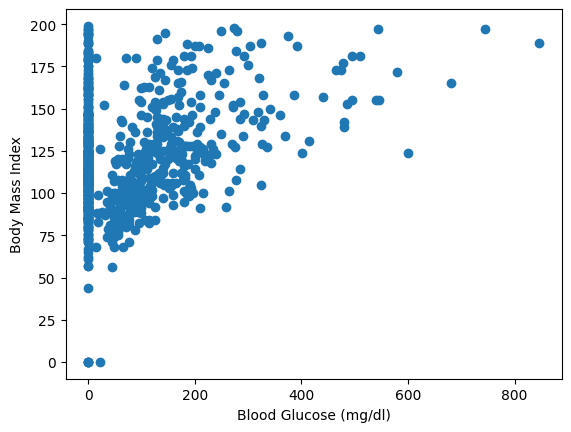

In [13]:
# Plotting Glucose vs body mass index

import matplotlib.pyplot as plt

plt.scatter(X_Bmi,Y)
plt.xlabel("Blood Glucose (mg/dl)")
plt.ylabel("Body Mass Index")
plt.show()

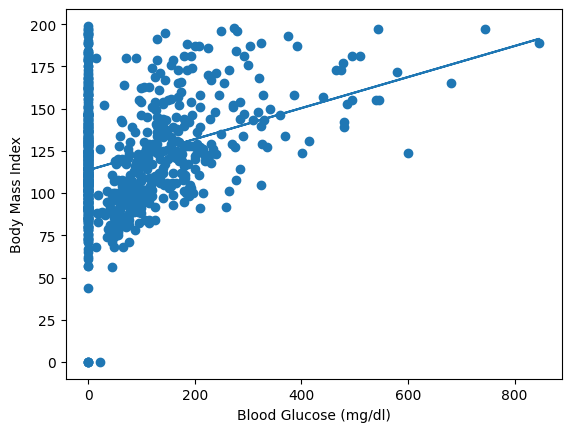

In [14]:
# Fitting Model

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_Bmi,Y)
predictions = reg.predict(X_Bmi)

plt.scatter(X_Bmi,Y)
plt.plot(X_Bmi, predictions)
plt.xlabel("Blood Glucose (mg/dl)")
plt.ylabel("Body Mass Index")
plt.show()


## Linear Regression with All Features

In [19]:
from  sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

X_train, X_test, y_train ,y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)

#Using Accuracy R-Square Metric
RSquare = reg.score(X_test,y_test)
print("The R-Squared for this :",RSquare)

The R-Squared for this : 0.28280468810375115


In [23]:
# Mean Squared Error
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_test,y_pred)


np.float64(26.341459582232265)

## Cross Validation


In [26]:
from sklearn.model_selection import cross_val_score,KFold
import numpy as np

kf = KFold(n_splits=6,shuffle=True,random_state=42)
reg = LinearRegression()

cv_results = cross_val_score(reg,X,Y,cv=kf)
print(cv_results)

[0.26207548 0.28228176 0.41203082 0.23785884 0.41634629 0.30398869]


In [27]:
print(np.mean(cv_results),np.std(cv_results))

0.3190969786734481 0.0701532061011418


In [28]:
print(np.quantile(cv_results,[0.25,0.975]))

[0.26712705 0.41580685]


## Regularized Regression

Why regularize?

1. Recall : Linear regression minimized a loss function.

2. It Chooses a coefficient, a, for each feature variable plus b.

3. Large Coefficient can lead to overfitting

4. Regularization : Penalized Large Coefficient

### Ridge Regression

In this Ridge regression, we penalize large positive or negative coeeficients

In [30]:
from sklearn.linear_model import Ridge

score = []

for alpha in [0.1,1.0,10.0,100.0,1000.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train,y_train)
    y_pred = ridge.predict(X_test)
    score.append(ridge.score(X_test,y_test))

print(score)

[0.2828466623222219, 0.2832063357480473, 0.2853000732200003, 0.2642398481266811, 0.19292424694100907]


### Lasso Regression

In [31]:
from sklearn.linear_model import Lasso

score = []

for alpha in [0.01,1.0,10.0,20.0,50.0]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train,y_train)
    y_pred = lasso.predict(X_test)
    score.append(lasso.score(X_test,y_test))

print(score)

[0.2831114455475573, 0.29795609755827845, 0.1798983878927387, 0.18127361610181125, 0.15679544303617965]


### Lasso regression for feature Selection

1. Lasso can select important features of a dataset

2. Shirnks the coefficients of less important features to zero

3. Features not shrunk to zero are selected by lasso

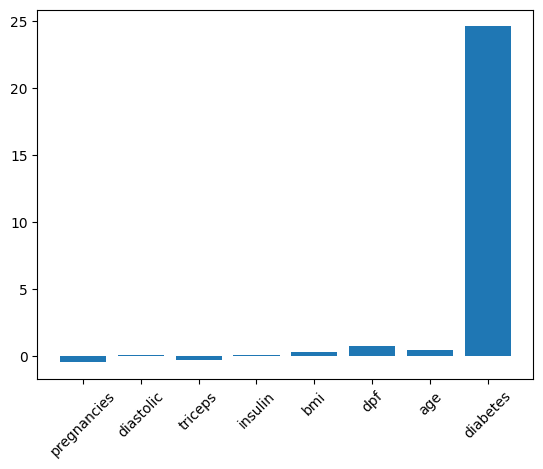

In [34]:
from sklearn.linear_model import Lasso


X = df.drop("glucose", axis=1).values
Y = df['glucose'].values

names = df.drop("glucose",axis=1).columns
lasso = Lasso(alpha=0.1)

lasso_coef = lasso.fit(X,Y).coef_
plt.bar(names, lasso_coef)
plt.xticks(rotation=45)
plt.show()
